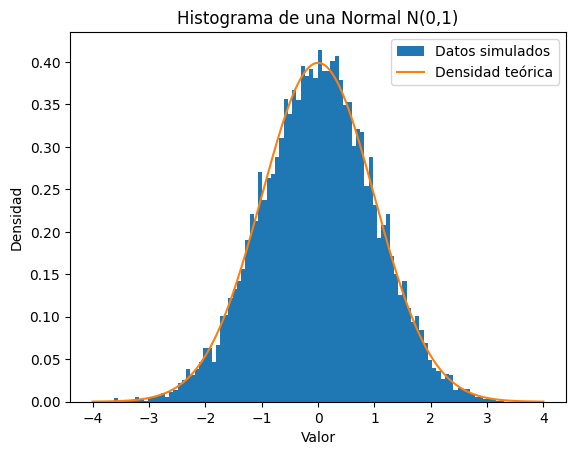

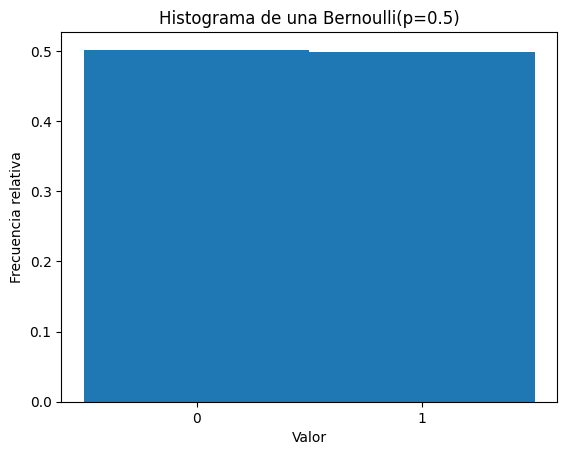

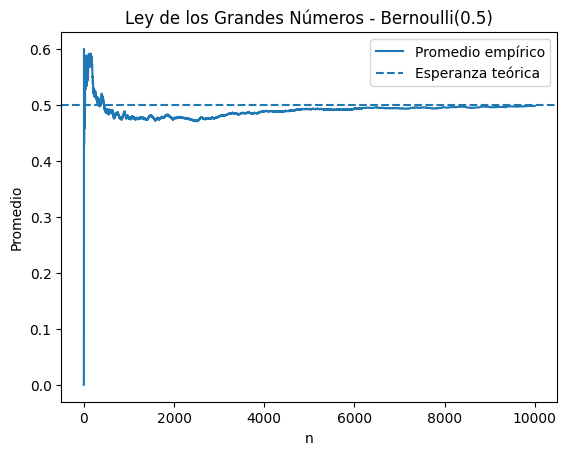

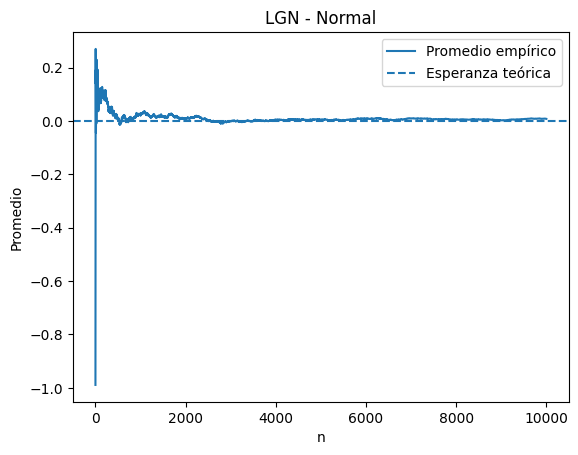

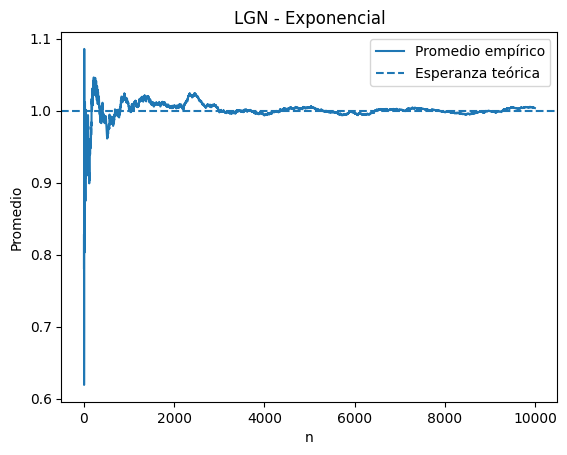

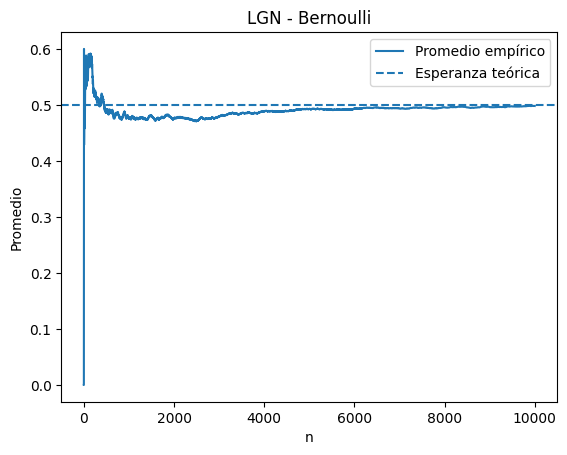

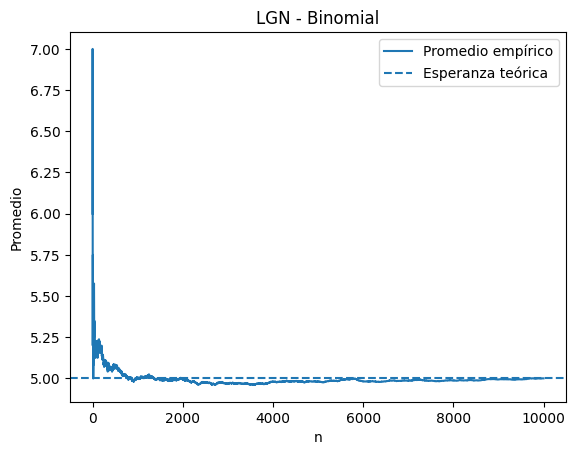

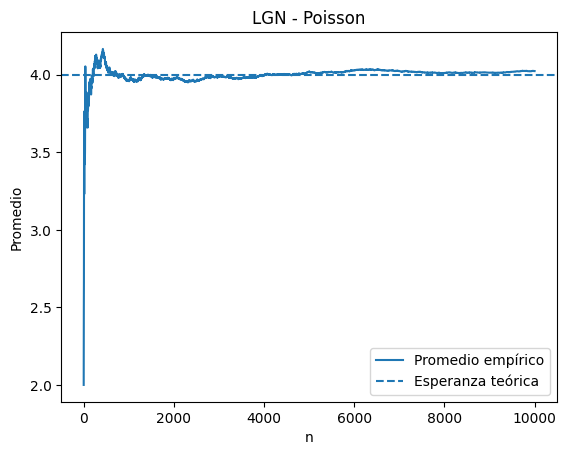

In [19]:
# Tarea 1 - Parte 1
## 1. Ley de los Grandes Números y Teorema Central del Límite

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEMILLA = 123
rng = np.random.default_rng(SEMILLA)

## 1.1. Simulación y distribución empírica
n = 10000
normal = rng.normal(loc=0, scale=1, size=n)
exponencial = rng.exponential(scale=1, size=n)
bernoulli = rng.binomial(n=1, p=0.5, size=n)
binomial = rng.binomial(n=10, p=0.5, size=n)
poisson = rng.poisson(lam=4, size=n)

datos = pd.DataFrame({
    "Normal": normal,
    "Exponencial": exponencial,
    "Bernoulli": bernoulli,
    "Binomial": binomial,
    "Poisson": poisson
})

datos.head()

### 1.1.1. Histograma de una variable continua: Normal
x = np.linspace(-4, 4, 500)

densidad_normal = (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)

plt.hist(
    datos["Normal"],
    bins=100,
    density=True,
    label="Datos simulados"
)

plt.plot(
    x,
    densidad_normal,
    label="Densidad teórica"
)

plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.title("Histograma de una Normal N(0,1)")
plt.legend()

plt.show()

#El histograma de las 10.000 realizaciones presenta una forma similar a la
#densidad teórica de una distribución Normal N(0,1). Al tener una cantidad
#grande de observaciones, la distribución empírica se aproxima a la
#distribución teórica.


### 1.1.2. Histograma de una variable discreta: Bernoulli
plt.hist(
    datos["Bernoulli"],
    bins=[-0.5, 0.5, 1.5],
    density=True
)

plt.xlabel("Valor")
plt.ylabel("Frecuencia relativa")
plt.title("Histograma de una Bernoulli(p=0.5)")

plt.xticks([0, 1])

plt.show()

#La variable Bernoulli solo puede tomar los valores 0 y 1. Como se utilizó
#p=0.5, ambos resultados tienen la misma probabilidad teórica, por lo que
#las frecuencias observadas deberían ser aproximadamente iguales.


## 1.2. Ley de los Grandes Números
sumas_acumuladas = datos.cumsum()
sumas_acumuladas.head()
numeros = np.arange(1, n + 1)
promedios = sumas_acumuladas.div(numeros, axis=0)
promedios.head()

esperanzas = {
    "Normal": 0,
    "Exponencial": 1,
    "Bernoulli": 0.5,
    "Binomial": 5,
    "Poisson": 4
}

plt.plot(promedios["Bernoulli"], label="Promedio empírico")

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Esperanza teórica"
)

plt.xlabel("n")
plt.ylabel("Promedio")
plt.title("Ley de los Grandes Números - Bernoulli(0.5)")
plt.legend()

plt.show()

for variable in datos.columns:

    plt.figure()

    plt.plot(
        promedios[variable],
        label="Promedio empírico"
    )

    plt.axhline(
        y=esperanzas[variable],
        linestyle="--",
        label="Esperanza teórica"
    )

    plt.xlabel("n")
    plt.ylabel("Promedio")
    plt.title(f"LGN - {variable}")
    plt.legend()

    plt.show()

### 1.2.1 Esperanzas teóricas

Para las distribuciones elegidas:

- Normal $N(0,1)$:

$$
E[X]=0
$$

- Exponencial con escala 1:

$$
E[X]=1
$$

- Bernoulli con $p=0.5$:

$$
E[X]=p=0.5
$$

- Binomial con $n=10$ y $p=0.5$:

$$
E[X]=np=10(0.5)=5
$$

- Poisson con $\lambda=4$:

$$
E[X]=\lambda=4
$$

## 1.3. TCL

Para ilustrar el TCL vamos a usar una variable aleatoria
Exponencial con parámetro 1.

En este caso:

$$
E[X]=1
$$

y

$$
Var(X)=1.
$$

Vamos a generar muchas muestras independientes de tamaño n y calcularemos
la media de cada muestra.

In [20]:
n_tcl = 30
N = 10000

muestras = rng.exponential(scale=1, size=(N, n_tcl))
medias_tcl = muestras.mean(axis=1)

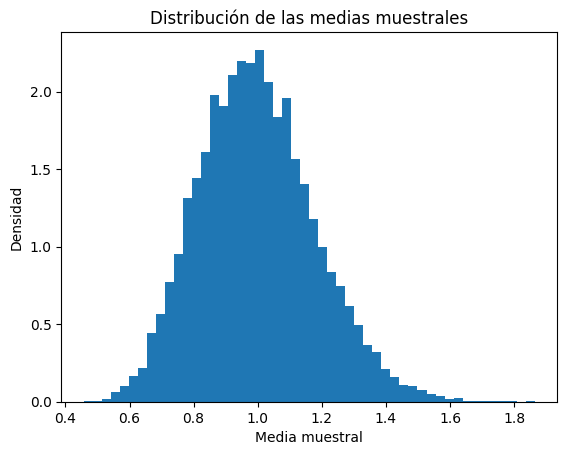

In [21]:
plt.hist(medias_tcl, bins=50, density=True)

plt.xlabel("Media muestral")
plt.ylabel("Densidad")
plt.title("Distribución de las medias muestrales")

plt.show()

Aunque la distribución Exponencial no es simétrica, la distribución de las
medias muestrales presenta una forma aproximadamente normal y se concentra
alrededor de la esperanza $E[X]=1$.

In [22]:
medias_normalizadas = np.sqrt(n_tcl) * (medias_tcl - 1)

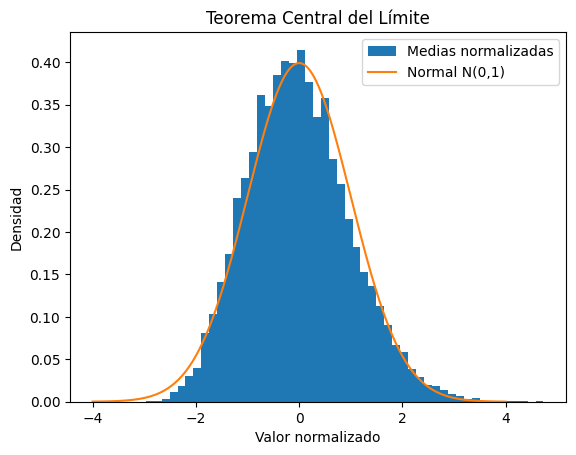

In [23]:
x = np.linspace(-4, 4, 500)

densidad_normal = (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)

plt.hist(
    medias_normalizadas,
    bins=50,
    density=True,
    label="Medias normalizadas"
)

plt.plot(
    x,
    densidad_normal,
    label="Normal N(0,1)"
)

plt.xlabel("Valor normalizado")
plt.ylabel("Densidad")
plt.title("Teorema Central del Límite")
plt.legend()

plt.show()

Después de centrar y normalizar las medias muestrales, su distribución se
aproxima a una Normal $N(0,1)$, como predice el Teorema Central del Límite.

Esto pasa aunque la variable original tenga una distribución Exponencial.

###1.3.1. Comparación entre LGN y TCL

La Ley de los Grandes Números muestra que, al aumentar el tamaño de la muestra, el promedio se va acercando al valor esperado. En cambio, el TCL muestra cómo se distribuyen esos promedios, tal que al tomar muchas muestras, las medias, después de centrarlas y normalizarlas, se aproximan a una distribución normal.